Iris

## 1. Load Dataset & Quick Checks

In [155]:
from ucimlrepo import fetch_ucirepo

iris = fetch_ucirepo(id=53)

X = iris.data.features
y = iris.data.targets

df = X.copy()
df["species"] = y.iloc[:, 0]

df.head()

,sepal length,sepal width,petal length,petal width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [156]:
df.columns

Index(['sepal length', 'sepal width', 'petal length', 'petal width',
       'species'],
      dtype='str')

In [157]:
df.shape

(150, 5)

In [158]:
df.dtypes

sepal length    float64
sepal width     float64
petal length    float64
petal width     float64
species             str
dtype: object

In [159]:
df.isna().sum()


sepal length    0
sepal width     0
petal length    0
petal width     0
species         0
dtype: int64

In [160]:
df.duplicated().sum()

np.int64(3)

three duplicates were found. Some flowers just look alike~ 🌸

## 2. Data Visualization

In [161]:
import matplotlib.pyplot as plt
import numpy as np

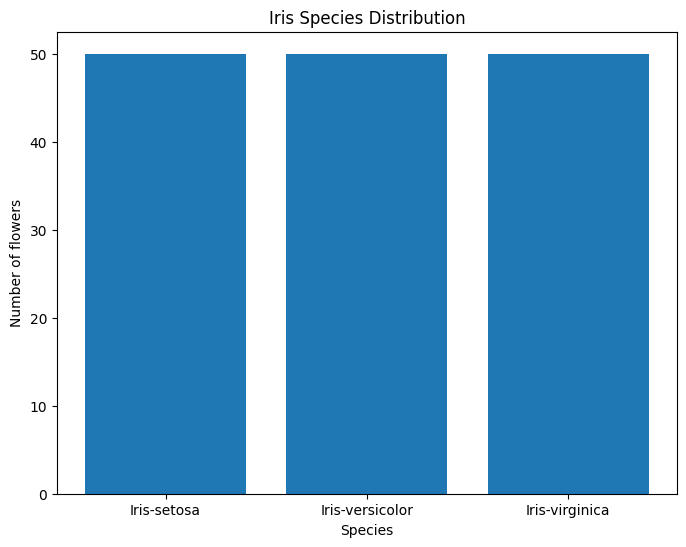

In [162]:
iris_counts = df["species"].value_counts()
plt.figure(figsize=(8, 6))
plt.bar(iris_counts.index, iris_counts.values)
plt.title("Iris Species Distribution")
plt.ylabel("Number of flowers")
plt.xlabel("Species")
plt.show()

perfectly balanced, as all things should be~

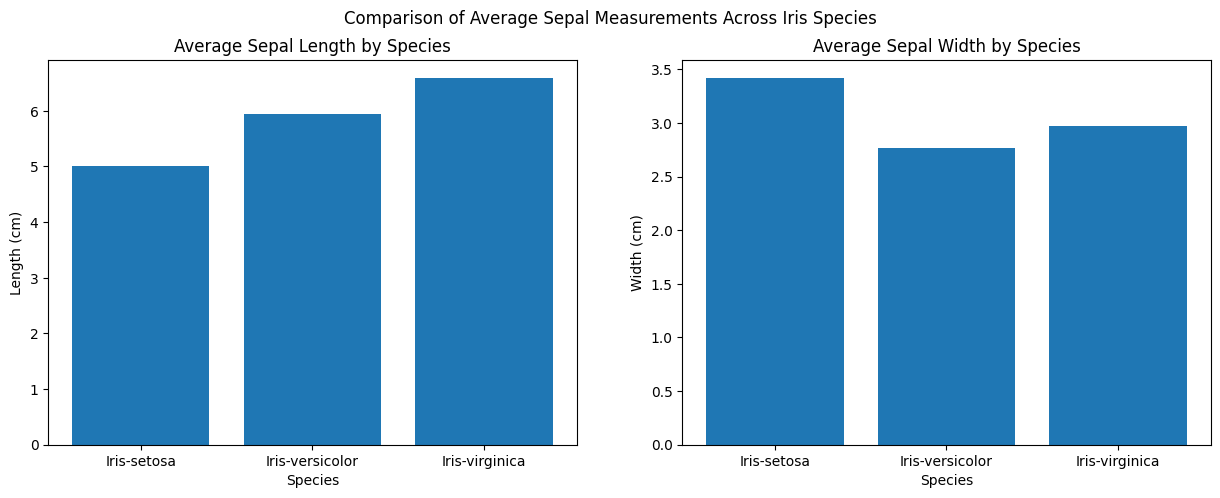

In [163]:
avg_sepal_length = df.groupby("species")["sepal length"].mean()
avg_sepal_width = df.groupby("species")["sepal width"].mean()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
fig.suptitle("Comparison of Average Sepal Measurements Across Iris Species")

ax[0].bar(avg_sepal_length.index, avg_sepal_length)
ax[0].set_title("Average Sepal Length by Species")
ax[0].set_xlabel('Species')
ax[0].set_ylabel("Length (cm)")


ax[1].bar(avg_sepal_width.index, avg_sepal_width)
ax[1].set_title("Average Sepal Width by Species")
ax[1].set_xlabel('Species')
ax[1].set_ylabel("Width (cm)")

plt.show()

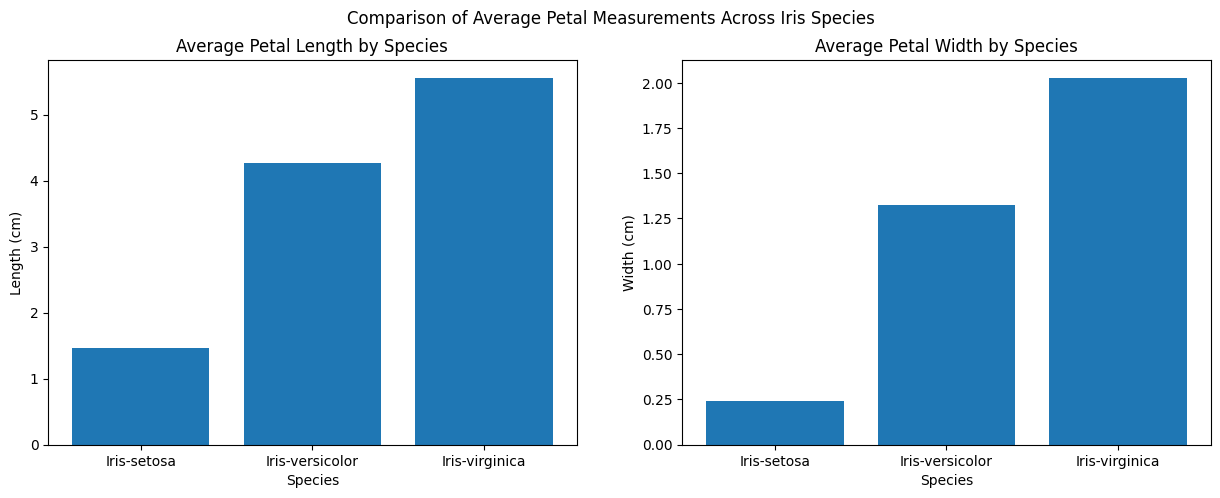

In [164]:
avg_petal_length = df.groupby("species")["petal length"].mean()
avg_petal_width = df.groupby("species")["petal width"].mean()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize =(15, 5))
fig.suptitle("Comparison of Average Petal Measurements Across Iris Species")

ax[0].bar(avg_petal_length.index, avg_petal_length)
ax[0].set_title("Average Petal Length by Species")
ax[0].set_xlabel("Species")
ax[0].set_ylabel("Length (cm)")

ax[1].bar(avg_petal_width.index, avg_petal_width)
ax[1].set_title("Average Petal Width by Species")
ax[1].set_xlabel("Species")
ax[1].set_ylabel("Width (cm)")

plt.show()

## 3. Preprocessing and Splitting

scaling for SVM, and target encoding.

In [165]:
X = df.drop(["species"], axis= 1)

y = df["species"]

In [166]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  150 non-null    float64
 1   sepal width   150 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [167]:
y.info()

<class 'pandas.Series'>
RangeIndex: 150 entries, 0 to 149
Series name: species
Non-Null Count  Dtype
--------------  -----
150 non-null    str  
dtypes: str(1)
memory usage: 1.3 KB


In [168]:
y.value_counts().index

Index(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype='str', name='species')

In [169]:
y = y.map({"Iris-setosa": 0,
           "Iris-versicolor": 1,
           "Iris-virginica": 2})

In [170]:
y.value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [171]:
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split

In [172]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    stratify= y,
    random_state= 42,
    shuffle=True    
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4. Model Training

In [173]:
import warnings
warnings.filterwarnings('ignore')

In [174]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import GridSearchCV

### 4.1 dumdum

In [175]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train,y_train)
dummy_y_pred = dummy.predict(X_test)
print(dummy_y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### 4.2 logistic regression

In [176]:
lr = LogisticRegression(random_state=42, max_iter=1000)

lr_para = {
    'solver': ['lbfgs'],
    'penalty': ['l2'],
    'C': [0.1, 1.0, 10.0]
}

best_lr = GridSearchCV(estimator=lr, param_grid= lr_para, cv=5)
best_lr.fit(X_train, y_train)
y_pred_best_lr = best_lr.predict(X_test)

print(y_pred_best_lr)

print("Winner Parameters:", best_lr.best_params_)
print("Best CV Score:", best_lr.best_score_)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
Winner Parameters: {'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score: 0.9666666666666668


### 4.3 decision tree

In [177]:
dt = DecisionTreeClassifier(random_state=42)

dt_para = {
    'criterion': ['gini'],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 10]
}

best_dt = GridSearchCV(estimator=dt, param_grid= dt_para, cv=5)
best_dt.fit(X_train,y_train)
y_pred_best_dt = best_dt.predict(X_test)

print(y_pred_best_dt)

print("Winner Parameters:", best_dt.best_params_)
print("Best CV Score:", best_dt.best_score_)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 2 1 0 2 0]
Winner Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
Best CV Score: 0.9416666666666668


### 4.4 random forest

In [178]:
rf = RandomForestClassifier(random_state=42)

rt_para = {
    'n_estimators':[50, 100],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt']
}

best_rf = GridSearchCV(estimator=rf, param_grid= rt_para, cv=5, n_jobs=1)
best_rf.fit(X_train,y_train)
y_pred_best_rf = best_rf.predict(X_test)

print(y_pred_best_rf)

print("Winner Parameters:",best_rf.best_params_)
print("Best CV Score:", best_rf.best_score_)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 2 1 0 2 0]
Winner Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 50}
Best CV Score: 0.95


### 4.5 gradient boosting

In [179]:
gb = GradientBoostingClassifier(random_state=42)

gb_para = {
    "learning_rate": [0.01, 0.1, 0.2],
    "n_estimators": [50, 100],
    "max_depth": [3, 5]
}

best_gb = GridSearchCV(estimator= gb, param_grid= gb_para, cv=5, n_jobs=1)
best_gb.fit(X_train,y_train)
y_pred_best_gb = best_gb.predict(X_test)

print(y_pred_best_gb)

print("Winner Parameters:", best_gb.best_params_)
print("Best CV Score:", best_gb.best_score_)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 2 2 2 1 0 2 0]
Winner Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Best CV Score: 0.9583333333333334


### 4.6 SVM

In [180]:
svm = SVC(random_state=42)

svm_para = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1.0, 10.0],
    'gamma': ['scale', 'auto']
}

best_svm = GridSearchCV(estimator= svm, param_grid= svm_para, cv=5, n_jobs=1)
best_svm.fit(X_train,y_train)
y_pred_best_svm = best_svm.predict(X_test)

print(y_pred_best_svm)

print("Winner Parameters:", best_svm.best_params_)
print("Best CV Score:", best_svm.best_score_)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]
Winner Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score: 0.975


## 5. Model Comparison

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = [dummy, best_dt, best_rf, best_gb, best_lr, best_svm]
model_names = ['Dummy Baseline', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'Logistic Regression', 'SVM']

rows = []

for name, model in zip(model_names, models):
    y_pred = model.predict(X_test)
    
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1-Score': f1_score(y_test, y_pred, average='macro')
    })

df_metrics = pd.DataFrame(rows)
df_metrics


,Model,Accuracy,Precision,Recall,F1-Score
0,Dummy Baseline,0.333333,0.111111,0.333333,0.166667
1,Decision Tree,0.900000,0.902357,0.900000,0.899749
2,Random Forest,0.900000,0.902357,0.900000,0.899749
3,Gradient Boosting,0.933333,0.933333,0.933333,0.933333
4,Logistic Regression,1.000000,1.000000,1.000000,1.000000
5,SVM,0.933333,0.933333,0.933333,0.933333


<Axes: xlabel='Model'>

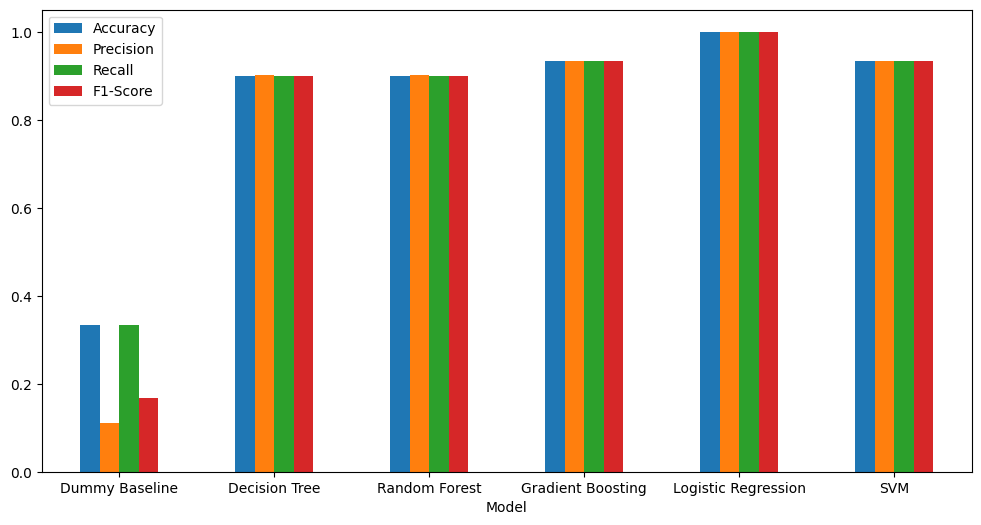

In [196]:
df_metrics.set_index('Model').plot(kind='bar', figsize=(12, 6), rot = 0)